# Title geography, two ways: tournament host country vs. language-mix-implied country

**Purpose:** answers a direct capability question (2026-09-09/10) — can
this project's data be shown on a color-coded world map, per title? Two
genuinely different sources, shown side by side rather than blended,
since they answer different questions:

1. **Where has a title's competitive scene actually been hosted** —
   `tournaments.country`, a real per-event fact, no proxy involved.
2. **What countries a title's Twitch audience is implied to skew toward**
   — `language_mix_snapshots.language_code`, a genuine proxy (a language
   isn't a country), and a much weaker claim than #1.

**Both maps hit the same core problem at different points, worth stating
up front rather than discovering per-chart**: real-world geography
doesn't collapse cleanly onto "one country per data point." A tournament
can be labeled "Europe" instead of a specific country; a language like
English or Spanish is spoken across many countries with no single
dominant one. Every country-level number below is built from a
**deliberately incomplete, explicitly documented** normalization — rows
that don't map confidently to one country are excluded and counted, not
guessed. Treat every map as a floor on real coverage, not a full picture.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import yaml
from plotly.subplots import make_subplots

# Static PNG output, not the interactive JSON widget -- consistent with
# every other notebook in this project (matplotlib PNGs, portable
# anywhere: GitHub's preview, a downloaded file, no live-kernel
# dependency). Costs hover interactivity in exchange for that portability.
pio.renderers.default = "png"

from etl.db import get_connection

with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]
display_name_by_id = {t["id"]: t["display_name"] for t in titles_config}

# One representative set for both map types, so the two are directly
# comparable per title -- spans PC-global-competitive (CS, Dota 2,
# League, VALORANT) and mobile/regional (Mobile Legends, Free Fire),
# chosen deliberately to include titles where one map type turns out
# sparse (CS, VALORANT below) rather than only picking titles that look
# good -- that sparsity is itself part of the honest answer.
TITLES = ["counter_strike", "dota2", "league_of_legends", "valorant", "mobile_legends_bb", "free_fire"]

## Map 1 — tournament host country

`tournaments.country` is a raw Liquipedia field, never normalized before
now. Checked directly (2026-09-09/10) against every tier-1/2 tournament
row: it's a real mess — actual countries in wildly inconsistent form
("USA" / "usa" / "US" / "United States" / "united states"), lowercase
ISO-2 codes mixed in ("kr", "de", "jp"), and, separately, a huge share of
rows that aren't a country at all — continents and macro-regions
("Europe", "CIS", "MENA", "SEA", "Nordic", "Benelux") or placeholders
("World", "TBD"). None of that was assumed — every distinct value in the
column was pulled and classified by hand.

In [2]:
# ISO-3 mapping, keyed on the lowercased raw string. Covers every genuine
# country/alias/2-letter-code actually observed in tournaments.country --
# built and tested against the real distinct-value distribution, not
# guessed at scale (tested: 8,429 of 16,300 tier-1/2 rows with a country
# value map cleanly, 7,870 are real continents/regions/placeholders
# (EXCLUDED_COUNTRY, below), and exactly 1 row -- "bs", genuinely
# ambiguous between Bahamas and Bosnia -- falls through unmapped).
COUNTRY_TO_ISO3 = {
    "united states": "USA", "usa": "USA", "us": "USA", "united states of america": "USA",
    "china": "CHN", "cn": "CHN",
    "south korea": "KOR", "korea": "KOR", "kr": "KOR",
    "brazil": "BRA", "brasil": "BRA", "br": "BRA",
    "japan": "JPN", "jp": "JPN",
    "germany": "DEU", "de": "DEU",
    "france": "FRA", "fr": "FRA",
    "taiwan": "TWN", "tw": "TWN",
    "sweden": "SWE", "se": "SWE",
    "australia": "AUS",
    "vietnam": "VNM", "vn": "VNM",
    "united kingdom": "GBR", "uk": "GBR", "england": "GBR", "scotland": "GBR",
    "thailand": "THA", "th": "THA",
    "malaysia": "MYS", "my": "MYS",
    "saudi arabia": "SAU", "sa": "SAU",
    "indonesia": "IDN",
    "canada": "CAN", "ca": "CAN",
    "india": "IND",
    "russia": "RUS", "ru": "RUS",
    "mexico": "MEX", "méxico": "MEX", "mx": "MEX",
    "philippines": "PHL",
    "poland": "POL", "pl": "POL",
    "ukraine": "UKR", "ua": "UKR",
    "turkey": "TUR", "turkiye": "TUR", "türkiye": "TUR", "tr": "TUR",
    "spain": "ESP", "es": "ESP",
    "finland": "FIN",
    "romania": "ROU", "ro": "ROU",
    "chile": "CHL",
    "italy": "ITA",
    "pakistan": "PAK",
    "netherlands": "NLD", "nl": "NLD",
    "united arab emirates": "ARE", "ae": "ARE",
    "south africa": "ZAF",
    "hong kong": "HKG",
    "peru": "PER",
    "belgium": "BEL",
    "denmark": "DNK", "dk": "DNK",
    "cambodia": "KHM",
    "norway": "NOR", "no": "NOR",
    "dominican republic": "DOM",
    "argentina": "ARG",
    "puerto rico": "PRI",
    "myanmar": "MMR",
    "ireland": "IRL", "ie": "IRL",
    "macau": "MAC",
    "kazakhstan": "KAZ",
    "greece": "GRC",
    "bulgaria": "BGR",
    "austria": "AUT", "at": "AUT",
    "bangladesh": "BGD",
    "costa rica": "CRI",
    "colombia": "COL",
    "portugal": "PRT",
    "belarus": "BLR", "by": "BLR",
    "azerbaijan": "AZE",
    "uzbekistan": "UZB",
    "serbia": "SRB",
    "new zealand": "NZL",
    "croatia": "HRV",
    "armenia": "ARM",
    "switzerland": "CHE", "ch": "CHE",
    "nepal": "NPL",
    "malta": "MLT",
    "madagascar": "MDG",
    "ivory coast": "CIV",
    "bolivia": "BOL",
    "qatar": "QAT",
    "mongolia": "MNG", "mn": "MNG",
    "laos": "LAO",
    "hungary": "HUN",
    "georgia": "GEO",
    "czech republic": "CZE", "czechia": "CZE", "cz": "CZE",
    "sint maarten": "SXM",
    "maldives": "MDV",
    "kuwait": "KWT",
    "israel": "ISR",
    "iran": "IRN",
    "iceland": "ISL",
    "brunei": "BRN",
    "venezuela": "VEN",
    "turkmenistan": "TKM",
    "tajikistan": "TJK",
    "slovenia": "SVN",
    "slovakia": "SVK", "sk": "SVK",
    "panama": "PAN",
    "morocco": "MAR",
    "lithuania": "LTU",
    "kyrgyzstan": "KGZ",
    "jordan": "JOR",
    "egypt": "EGY",
    "cyprus": "CYP",
    "andorra": "AND",
    "singapore": "SGP", "sg": "SGP",
}

# Continents, macro-regions, and placeholders -- real values, but not a
# single country, so excluded rather than force-mapped to one arbitrary
# member. "kosovo" included here too: a real place, but no standard ISO-3
# code in plotly's built-in reference.
EXCLUDED_COUNTRY = {
    "north america", "europe", "world", "south america", "asia", "oceania",
    "southeast asia", "middle east", "cis", "americas", "africa", "mena",
    "asia-pacific", "south asia", "latin america", "apac", "east asia",
    "sea", "latin america north", "emea", "central america", "latam",
    "global", "northeast asia", "asia pacific", "sub-saharan africa",
    "middle east and north africa", "oce", "eu", "benelux", "nordic",
    "nordics", "western europe", "eastern europe", "latin america south",
    "las", "lan", "tbd", "north americas", "kosovo",
}

conn = get_connection()
country_rows = conn.execute(
    "SELECT title_id, country FROM tournaments WHERE tier IN ('1','2') AND country IS NOT NULL"
).fetchall()
conn.close()

country_df = pd.DataFrame(country_rows, columns=["title_id", "country_raw"])
country_df["key"] = country_df["country_raw"].str.strip().str.lower()
country_df["iso3"] = country_df["key"].map(COUNTRY_TO_ISO3)

n_total = len(country_df)
n_mapped = country_df["iso3"].notna().sum()
n_excluded = country_df["key"].isin(EXCLUDED_COUNTRY).sum()
n_unmapped = n_total - n_mapped - n_excluded
print(f"{n_total} tier-1/2 tournament rows with a country value")
print(f"  {n_mapped} ({n_mapped/n_total*100:.1f}%) map to a specific country")
print(f"  {n_excluded} ({n_excluded/n_total*100:.1f}%) are a continent/region/placeholder, excluded")
print(f"  {n_unmapped} ({n_unmapped/n_total*100:.1f}%) unmapped (genuinely unclear) -- not guessed")

16300 tier-1/2 tournament rows with a country value
  8429 (51.7%) map to a specific country
  7870 (48.3%) are a continent/region/placeholder, excluded
  1 (0.0%) unmapped (genuinely unclear) -- not guessed


**Nearly half of all tier-1/2 tournament rows use a continent or region,
not a country, as their location field** — a real finding about how
Liquipedia editors record tournament geography, not a gap in this
project's parsing. Read every map below as "of the events that *did*
name a specific country," not "of every event."

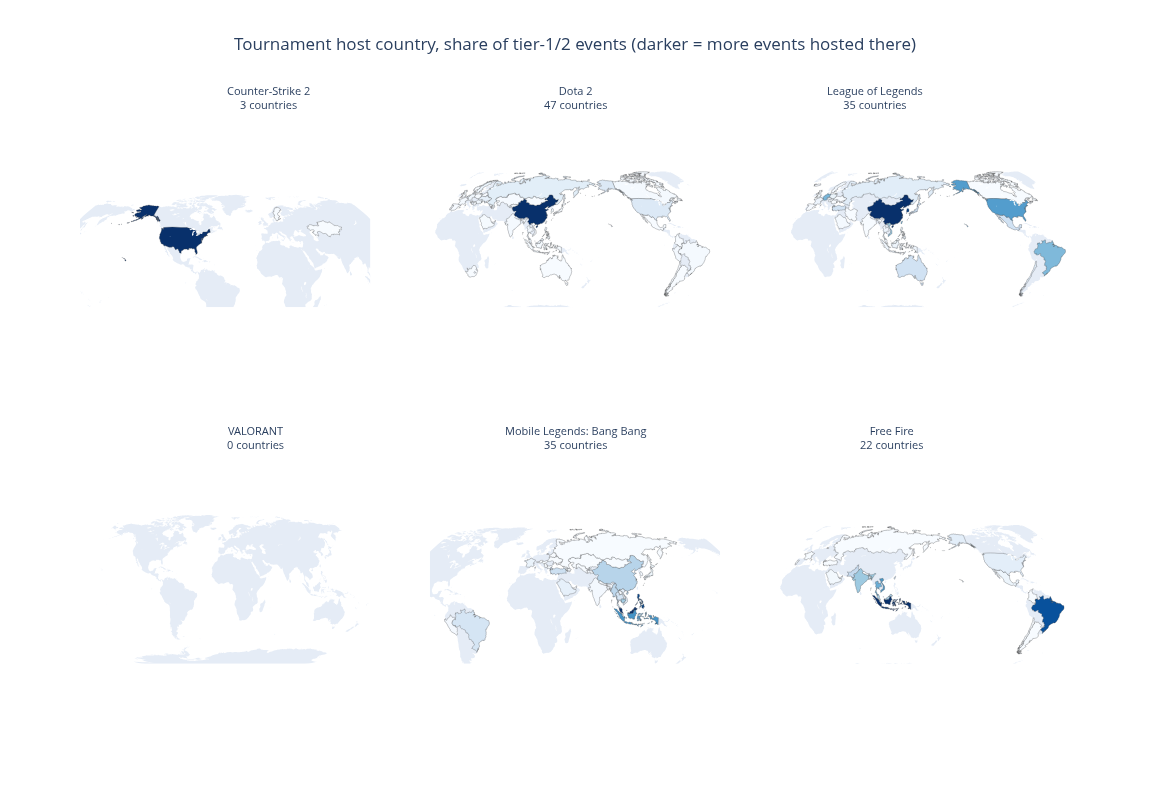

In [3]:
def country_shares(title_id: str) -> pd.DataFrame:
    sub = country_df[(country_df["title_id"] == title_id) & country_df["iso3"].notna()]
    counts = sub.groupby("iso3").size().rename("count").reset_index()
    counts["share_pct"] = counts["count"] / counts["count"].sum() * 100
    return counts

fig = make_subplots(
    rows=2, cols=3,
    specs=[[{"type": "choropleth"}] * 3] * 2,
    horizontal_spacing=0.06, vertical_spacing=0.15,
)

# subplot_titles (make_subplots' built-in title mechanism) mispositions
# its annotations for a multi-row choropleth grid specifically -- checked
# directly (row-2 titles collided with row-1 maps no matter how much
# vertical_spacing/height was increased). Positioned manually instead,
# from each geo subplot's own actual domain -- reliable regardless of
# projection/aspect quirks.
for i, title_id in enumerate(TITLES):
    row, col = divmod(i, 3)
    shares = country_shares(title_id)
    n_countries = len(shares)
    fig.add_trace(
        go.Choropleth(
            locations=shares["iso3"], z=shares["share_pct"],
            locationmode="ISO-3", colorscale="Blues",
            showscale=False, marker_line_width=0.3,
            hovertemplate="%{location}: %{z:.1f}%<extra></extra>",
        ),
        row=row + 1, col=col + 1,
    )
    geo_key = "geo" if i == 0 else f"geo{i + 1}"
    dom = fig.layout[geo_key].domain
    fig.add_annotation(
        text=f"{display_name_by_id[title_id]}<br>{n_countries} countries",
        xref="paper", yref="paper",
        x=(dom.x[0] + dom.x[1]) / 2, y=dom.y[1] + 0.03,
        showarrow=False, font=dict(size=11),
    )

fig.update_geos(showframe=False, showcoastlines=False, projection_type="natural earth")
fig.update_layout(height=800, width=1150, title_text="Tournament host country, share of tier-1/2 events (darker = more events hosted there)", title_x=0.5)
fig.show()

**Read**: Dota 2, League of Legends, and StarCraft II (not shown here,
richest of all 23 titles at 52 distinct countries — checked while
picking this set) have genuinely global, many-country hosting patterns.
Counter-Strike and VALORANT look almost **empty** on this map — not
because their scenes are geographically thin (both are among the
largest tracked titles by every other metric in this project), but
because their tournament organizers overwhelmingly label events by
region ("Europe," "Americas," "World") rather than host city/country —
confirmed directly: Counter-Strike has only 10 tier-1/2 tournament rows
at all (out of 11,434 total rows for the title — the rest is B/C-tier
grassroots data, not eligible for a tier-1/2-only map), and of those 10,
only 3 distinct countries are ever named; the other 7 use a region label.
**This map type structurally favors titles/organizers that record a
specific host country** — it is not a neutral measure of geographic
reach, and CS/VALORANT's near-blank maps are the clearest illustration
of that in this dataset.

## Map 2 — language-mix-implied country

The counterpart to `research/foundations/fandom_and_niche_model/notebooks/niche_membership.ipynb`'s `LANGUAGE_TO_REGION`
(continent-level) — extended one level further to specific countries,
**more conservatively than that mapping**, not just a finer version of
it. Two languages that were "safe" at continent granularity there (`zh`,
`ar`) are excluded here entirely: Chinese spans mainland China, Taiwan,
Hong Kong, and Singapore, and Twitch is itself effectively inaccessible
in mainland China, so a `zh` viewer skews toward Taiwan/HK/diaspora, not
a single confident country; Arabic spans dozens of countries with no
dominant one. `en`/`es`/`other` stay excluded for the same reason the
original notebook excluded them.

In [4]:
# Extends niche_membership.ipynb's LANGUAGE_TO_REGION -- same included
# language set, refined to a single specific country where one is
# genuinely dominant (rather than just "a confident continent"). "pt" ->
# Brazil carries the same medium-confidence caveat that notebook already
# documented (Portugal exists too, but Twitch's Portuguese-speaking base
# skews heavily Brazil).
LANGUAGE_TO_COUNTRY = {
    "ko": "KOR", "ja": "JPN", "th": "THA", "vi": "VNM", "id": "IDN", "tl": "PHL",
    "hi": "IND", "ms": "MYS", "he": "ISR",
    "ru": "RUS", "de": "DEU", "fr": "FRA", "it": "ITA", "pl": "POL", "tr": "TUR",
    "uk": "UKR", "cs": "CZE", "hu": "HUN", "el": "GRC", "fi": "FIN", "sv": "SWE",
    "da": "DNK", "no": "NOR", "nl": "NLD", "ro": "ROU", "bg": "BGR", "sk": "SVK",
    "hr": "HRV", "pt": "BRA",
}
AMBIGUOUS_LANGUAGES = {"en", "es", "zh", "ar", "other"}

conn = get_connection()
lang_rows = conn.execute(
    "SELECT title_id, language_code, SUM(viewer_count) AS viewer_time "
    "FROM language_mix_snapshots WHERE title_id IN ({}) GROUP BY title_id, language_code".format(
        ",".join("?" * len(TITLES))
    ),
    TITLES,
).fetchall()
conn.close()

lang_df = pd.DataFrame(lang_rows, columns=["title_id", "language_code", "viewer_time"])
lang_df["iso3"] = lang_df["language_code"].map(LANGUAGE_TO_COUNTRY)
title_totals = lang_df.groupby("title_id")["viewer_time"].transform("sum")
lang_df["share_of_title_pct"] = lang_df["viewer_time"] / title_totals * 100

for title_id in TITLES:
    sub = lang_df[lang_df["title_id"] == title_id]
    mapped_pct = sub[sub["iso3"].notna()]["share_of_title_pct"].sum()
    print(f"{display_name_by_id[title_id]:20s} {mapped_pct:5.1f}% of viewer-time maps to a specific country")

Counter-Strike 2      75.6% of viewer-time maps to a specific country
Dota 2                80.7% of viewer-time maps to a specific country
League of Legends     38.8% of viewer-time maps to a specific country
VALORANT              39.5% of viewer-time maps to a specific country
Mobile Legends: Bang Bang  93.2% of viewer-time maps to a specific country
Free Fire             24.5% of viewer-time maps to a specific country


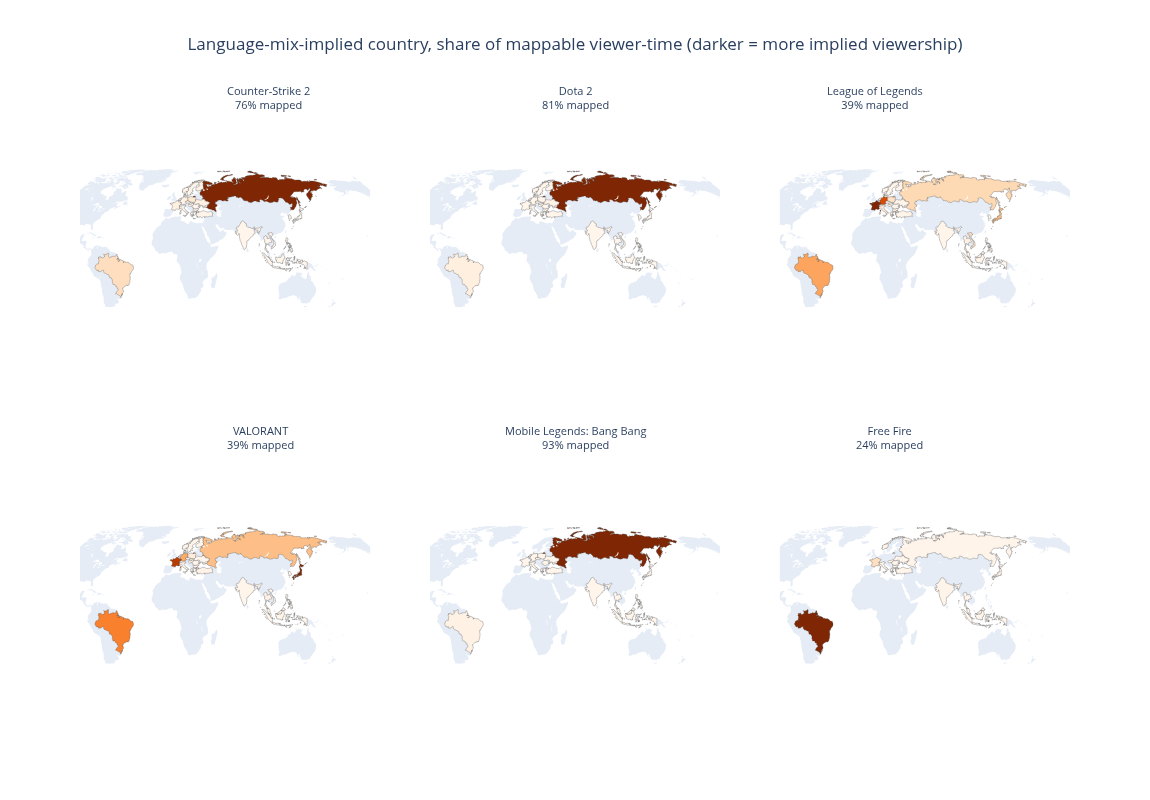

In [5]:
def lang_country_shares(title_id: str) -> pd.DataFrame:
    sub = lang_df[(lang_df["title_id"] == title_id) & lang_df["iso3"].notna()]
    grouped = sub.groupby("iso3")["share_of_title_pct"].sum().reset_index()
    return grouped

fig = make_subplots(
    rows=2, cols=3,
    specs=[[{"type": "choropleth"}] * 3] * 2,
    horizontal_spacing=0.06, vertical_spacing=0.15,
)

# Manual annotation positioning again -- see Map 1's own comment for why.
for i, title_id in enumerate(TITLES):
    row, col = divmod(i, 3)
    shares = lang_country_shares(title_id)
    fig.add_trace(
        go.Choropleth(
            locations=shares["iso3"], z=shares["share_of_title_pct"],
            locationmode="ISO-3", colorscale="Oranges",
            showscale=False, marker_line_width=0.3,
            hovertemplate="%{location}: %{z:.1f}%<extra></extra>",
        ),
        row=row + 1, col=col + 1,
    )
    mapped_total = shares["share_of_title_pct"].sum()
    geo_key = "geo" if i == 0 else f"geo{i + 1}"
    dom = fig.layout[geo_key].domain
    fig.add_annotation(
        text=f"{display_name_by_id[title_id]}<br>{mapped_total:.0f}% mapped",
        xref="paper", yref="paper",
        x=(dom.x[0] + dom.x[1]) / 2, y=dom.y[1] + 0.03,
        showarrow=False, font=dict(size=11),
    )

fig.update_geos(showframe=False, showcoastlines=False, projection_type="natural earth")
fig.update_layout(height=800, width=1150, title_text="Language-mix-implied country, share of mappable viewer-time (darker = more implied viewership)", title_x=0.5)
fig.show()

**Mobile Legends: Bang Bang's map was the one surprise, and a deeper dig
(2026-09-10) found the first-pass explanation here was overstated.** The
map shows overwhelming Russia concentration (`ru` at **89.9%** of all
its viewer-time this window). The first version of this note attributed
that mostly to one live CIS-region tournament overlapping the capture
window — checked more rigorously since, and that explanation covers only
a small part of it: only **10.5%** of MLBB's Russian viewer-time is
tournament-broadcast-tagged (`broadcast_tier='detected_costream'`); the
other ~90% is ordinary, untagged community streaming, spread across
**422 distinct Russian-language channels — 53.4% of MLBB's entire
791-channel Twitch creator base**, with no single channel dominating
(top 10 channels are only 50.9% of the Russian total) and a daily share
that stayed flat at 89.6%-92.1% across all 10 days of the window, not
spiking around specific match dates. That's a broad, sustained community
signal, not a tournament artifact. Full investigation, including a
cross-title check (PUBG Mobile shows an even stronger, **fully organic**
version of this pattern) and absolute-scale numbers, not just share:
`research/exploratory/notebooks/mlbb_russia_deep_dive.ipynb`.


## Caveats

- **These two maps measure genuinely different things and should never
  be read as agreeing or disagreeing with each other without checking
  their own coverage numbers first.** A title can look "hosted everywhere"
  on Map 1 while its audience-language map is thin, or vice versa —
  that's real information, not a contradiction to resolve.
- **Every country shown is a floor, not a ceiling**, on both maps — rows
  that don't map confidently are excluded and counted, never guessed.
  Re-derive `COUNTRY_TO_ISO3`/`LANGUAGE_TO_COUNTRY` if either project's
  underlying data changes shape enough that the exclusion-rate numbers
  above look meaningfully different.
- **`language_mix_snapshots` is still a short window**
  (`research/foundations/fandom_and_niche_model/notebooks/niche_membership.ipynb`'s own caveat applies here identically — a few
  days of hourly polls, not a seasonally-averaged baseline, and exposed
  to the same live-tournament contamination risk that notebook checks
  for directly). Re-run this notebook once that table has weeks or
  months of history before treating any single country's share as
  settled.
- **Not every one of the 23 tracked titles is shown** — `TITLES` above is
  a deliberately chosen 6-title comparison set, not a claim that the
  other 17 don't have interesting maps. Swap `TITLES` and re-run for any
  other title; the two normalization dicts above already cover every
  language/country actually seen across all 23.